# SMS Spam Detection

A comparative study of 6 machine learning classifiers for detecting spam SMS messages.

**Models evaluated:**
- Naive Bayes
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Support Vector Machine (SVM)
- Random Forest

**Dataset:** [SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)  
**Technique:** TF-IDF vectorization + SMOTE for class imbalance handling

## 1. Install Required Libraries

In [1]:
!pip install pandas scikit-learn matplotlib seaborn imbalanced-learn joblib

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

## 3. Load and Explore Dataset

> **Note:** Place `spam.csv` in the same directory as this notebook.  
> Download it from [Kaggle](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset).

In [4]:
# Load the CSV dataset and select relevant columns
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']  # Rename columns for clarity

print("Dataset Loaded Successfully")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nLabel Distribution:")
print(df['label'].value_counts())

Dataset Loaded Successfully
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


## 4. Data Preprocessing

- Encode labels (ham=0, spam=1)
- TF-IDF vectorization
- Handle class imbalance with **SMOTE** (applied only to training data)

In [5]:
# Convert text labels to numerical values (ham=0, spam=1)
df['label_num'] = LabelEncoder().fit_transform(df['label'])

X = df['message']
y = df['label_num']

# Train/test split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Apply SMOTE to balance training classes
print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
smote = SMOTE(random_state=42)
X_train_tfidf, y_train = smote.fit_resample(X_train_tfidf, y_train)
print("After SMOTE: ", dict(pd.Series(y_train).value_counts()))

print("\nPreprocessing complete.")

Before SMOTE: {0: np.int64(3860), 1: np.int64(597)}
After SMOTE:  {0: np.int64(3860), 1: np.int64(3860)}

Preprocessing complete.


## 5. Model Training & Evaluation

Helper function to train, predict, and display results.

In [6]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train a model, print metrics, and display the confusion matrix."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return acc, model

### 5.1 — Naive Bayes


  Naive Bayes
Accuracy: 0.9650
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       965
        spam       0.84      0.92      0.88       150

    accuracy                           0.97      1115
   macro avg       0.91      0.95      0.93      1115
weighted avg       0.97      0.97      0.97      1115



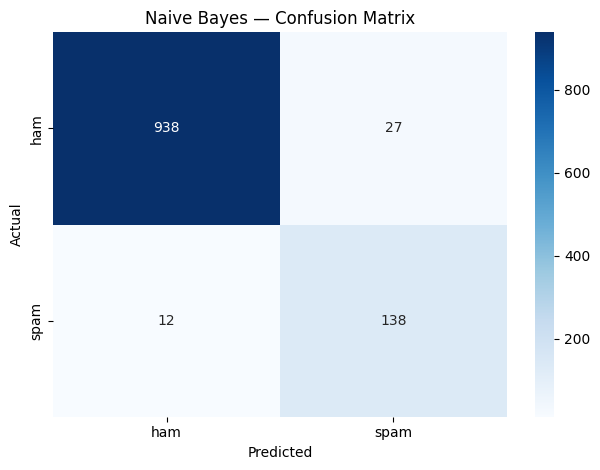

In [7]:
acc_nb, nb = evaluate_model(
    "Naive Bayes", MultinomialNB(),
    X_train_tfidf, y_train, X_test_tfidf, y_test
)

### 5.2 — Logistic Regression


  Logistic Regression
Accuracy: 0.9758
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       965
        spam       0.92      0.89      0.91       150

    accuracy                           0.98      1115
   macro avg       0.95      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



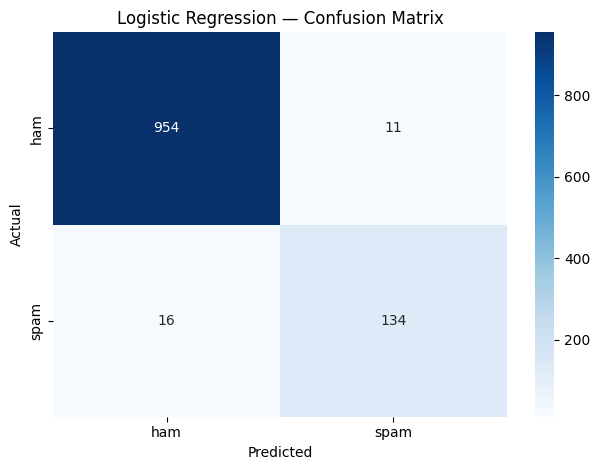

In [8]:
acc_lr, lr = evaluate_model(
    "Logistic Regression", LogisticRegression(max_iter=1000),
    X_train_tfidf, y_train, X_test_tfidf, y_test
)

### 5.3 — K-Nearest Neighbors


  K-Nearest Neighbors (k=3)
Accuracy: 0.9614
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.71      0.83       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



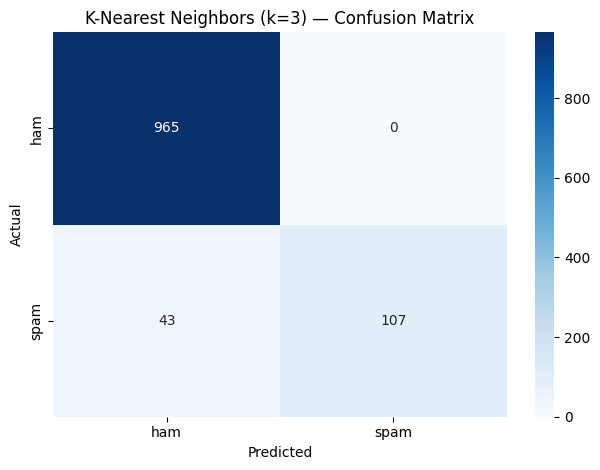

In [9]:
acc_knn, knn = evaluate_model(
    "K-Nearest Neighbors (k=3)", KNeighborsClassifier(n_neighbors=3),
    X_train_tfidf, y_train, X_test_tfidf, y_test
)

### 5.4 — Decision Tree


  Decision Tree
Accuracy: 0.9632
              precision    recall  f1-score   support

         ham       0.97      0.98      0.98       965
        spam       0.89      0.83      0.86       150

    accuracy                           0.96      1115
   macro avg       0.93      0.91      0.92      1115
weighted avg       0.96      0.96      0.96      1115



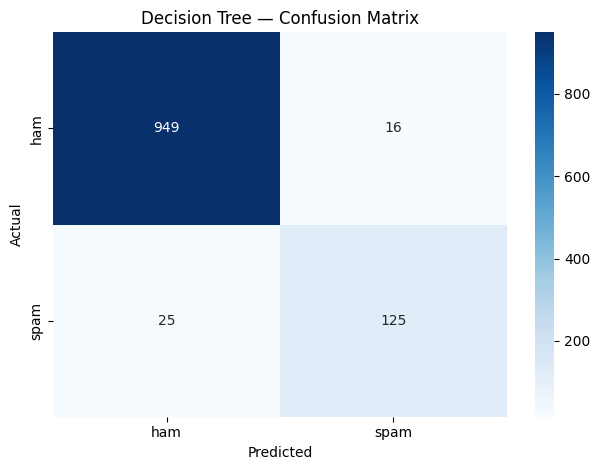

In [10]:
acc_dt, dt = evaluate_model(
    "Decision Tree", DecisionTreeClassifier(random_state=42),
    X_train_tfidf, y_train, X_test_tfidf, y_test
)

### 5.5 — Support Vector Machine


  Support Vector Machine
Accuracy: 0.9821
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.95      0.91      0.93       150

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



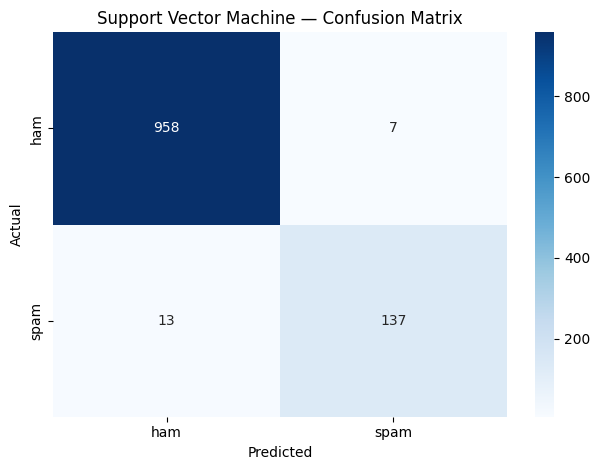

In [11]:
acc_svm, svm = evaluate_model(
    "Support Vector Machine", LinearSVC(),
    X_train_tfidf, y_train, X_test_tfidf, y_test
)

### 5.6 — Random Forest


  Random Forest
Accuracy: 0.9785
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.98      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



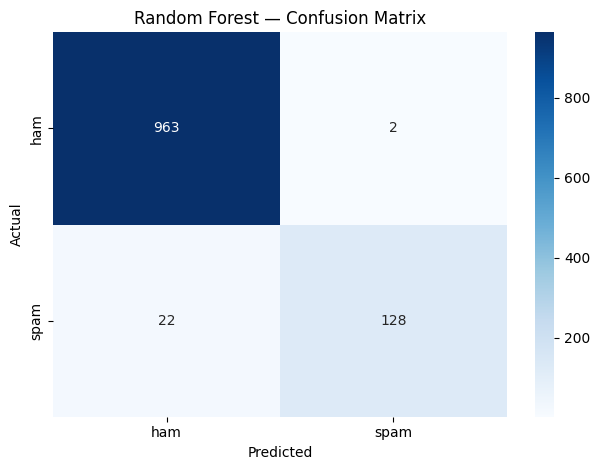

In [12]:
acc_rf, rf = evaluate_model(
    "Random Forest", RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_tfidf, y_train, X_test_tfidf, y_test
)

## Step 6 — Model Comparison

              Model  Accuracy
                SVM  0.982063
      Random Forest  0.978475
Logistic Regression  0.975785
        Naive Bayes  0.965022
      Decision Tree  0.963229
                KNN  0.961435


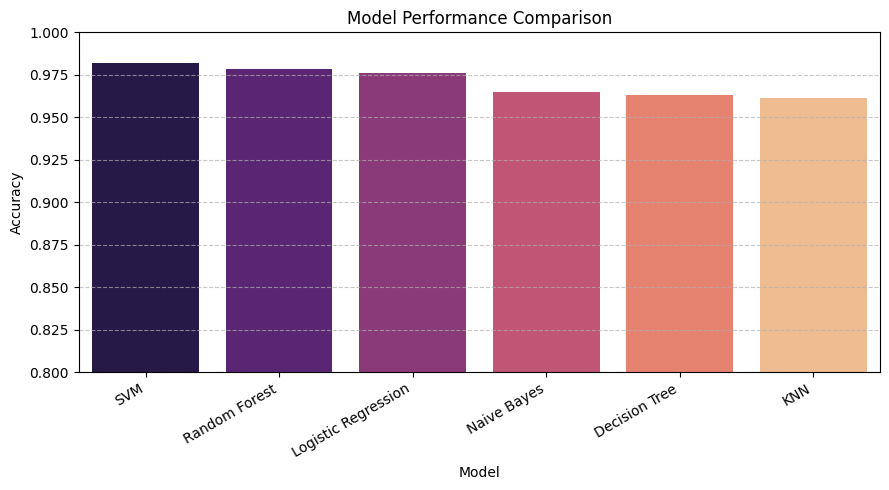

In [13]:
results = pd.DataFrame({
    'Model':    ['Naive Bayes', 'Logistic Regression', 'KNN', 'Decision Tree', 'SVM', 'Random Forest'],
    'Accuracy': [acc_nb, acc_lr, acc_knn, acc_dt, acc_svm, acc_rf]
})

results_sorted = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results_sorted.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 5))
sns.barplot(
    x='Model', y='Accuracy', data=results_sorted,
    hue='Model', palette='magma', legend=False
)
plt.title("Model Performance Comparison")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Step 7 — Save Best Model

In [17]:
import os

# Map model names to trained objects
model_map = {
    'Naive Bayes':        nb,
    'Logistic Regression': lr,
    'KNN':                knn,
    'Decision Tree':      dt,
    'SVM':                svm,
    'Random Forest':      rf,
}

best_row   = results.loc[results['Accuracy'].idxmax()]
best_name  = best_row['Model']
best_acc   = best_row['Accuracy']
best_model = model_map[best_name]

print(f"Best Model : {best_name}")
print(f"Accuracy   : {best_acc:.4f}")

# Create the 'models' directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model and vectorizer
joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(tfidf,      "models/tfidf_vectorizer.pkl")
print("\nSaved to models/best_model.pkl and models/tfidf_vectorizer.pkl")

Best Model : SVM
Accuracy   : 0.9821

Saved to models/best_model.pkl and models/tfidf_vectorizer.pkl


## Step 8 — Predict on Custom Messages

In [21]:
def predict_message(message, model, vectorizer):
    """Classify a single SMS message as spam or ham."""
    vec = vectorizer.transform([message])
    pred = model.predict(vec)[0]
    label = "SPAM" if pred == 1 else "HAM"
    print(f"Message : {message}")
    print(f"Result  : {label}\n")

# Example predictions
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify now to avoid charges.",
    "Can you pick up some milk on your way home?"
]

loaded_model = joblib.load("models/best_model.pkl")
loaded_tfidf  = joblib.load("models/tfidf_vectorizer.pkl")

for msg in test_messages:
    predict_message(msg, loaded_model, loaded_tfidf)

Message : Congratulations! You've won a FREE iPhone. Click here to claim now!
Result  : SPAM

Message : Hey, are we still meeting for lunch tomorrow?
Result  : HAM

Message : URGENT: Your account has been suspended. Verify now to avoid charges.
Result  : SPAM

Message : Can you pick up some milk on your way home?
Result  : HAM

